# Customer Churn Prediction Project


# Install required libraries

In [1]:
!pip -q install imbalanced-learn xgboost

# Import libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Upload and load dataset

In [3]:
from google.colab import files
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)
df.head()

Saving telecom_churn_data.csv to telecom_churn_data.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


# Data Inspection and Cleaning

In [4]:
print("Shape:", df.shape)
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())

if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

df = df.drop_duplicates().copy()
df.head()

Shape: (7043, 21)

Missing values:


,0
gender,5
TotalCharges,5
PaperlessBilling,2
MonthlyCharges,2
customerID,0
Dependents,0
Partner,0
SeniorCitizen,0
tenure,0
OnlineSecurity,0



Duplicate rows: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis

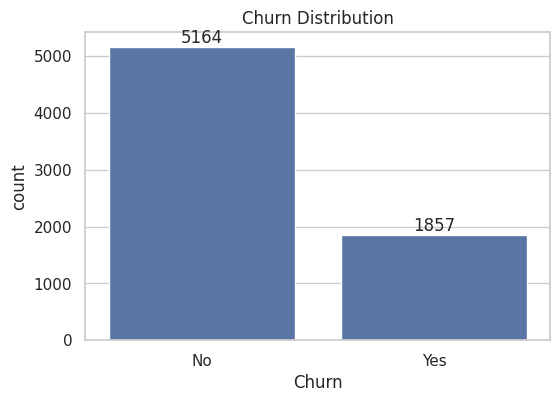

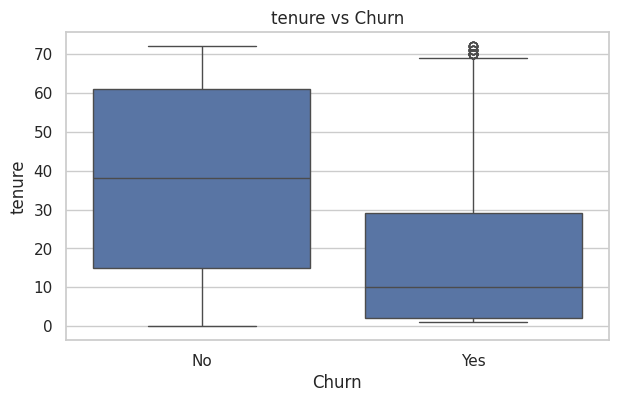

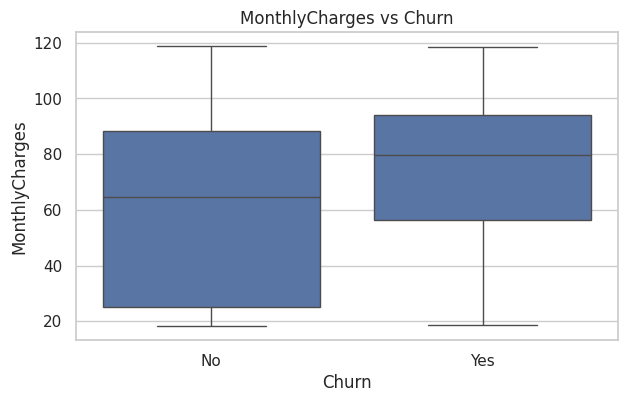

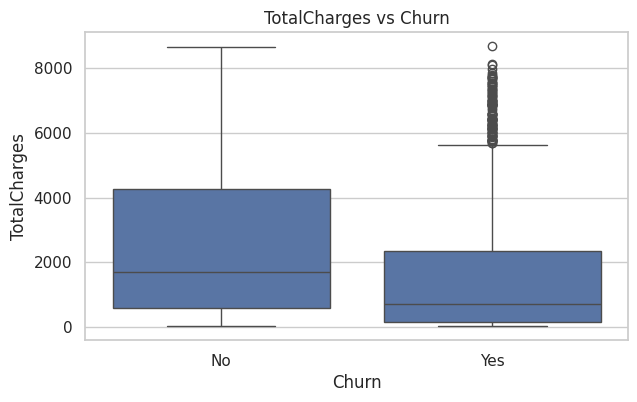

In [5]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

for col in [c for c in numeric_cols if c != "SeniorCitizen"]:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} vs Churn")
    plt.show()

# Feature Engineering and Preprocessing

In [6]:
df_model = df.copy()

for col in [c for c in ["tenure", "MonthlyCharges", "TotalCharges"] if c in df_model.columns]:
    q1 = df_model[col].quantile(0.25)
    q3 = df_model[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_model[col] = df_model[col].clip(lower=lower, upper=upper)

y = df_model["Churn"].map({"No": 0, "Yes": 1})
X = df_model.drop(columns=["Churn"]).copy()

if "SeniorCitizen" in X.columns:
    X["SeniorCitizen"] = X["SeniorCitizen"].astype(str)

num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(5616, 19) (1405, 19)


# Model Building and Training

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=300),
    "SVC": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42, eval_metric="logloss", n_estimators=300,
        learning_rate=0.05, max_depth=4, subsample=0.9, colsample_bytree=0.9
    )
}

results = []
trained_models = {}

for name, model in models.items():
    pipe = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    trained_models[name] = pipe
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.787900,0.586854,0.672043,0.626566,0.840486
1,Logistic Regression,0.748754,0.517179,0.768817,0.618378,0.840304
2,XGBoost,0.786477,0.597297,0.594086,0.595687,0.836541
3,SVC,0.774377,0.560175,0.688172,0.617612,0.822801
4,Random Forest,0.775801,0.584570,0.529570,0.555712,0.814011
5,KNN,0.699644,0.457192,0.717742,0.558577,0.763714
6,Decision Tree,0.730249,0.491139,0.521505,0.505867,0.664314


# Best Model Evaluation

Best baseline model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1033
           1       0.59      0.67      0.63       372

    accuracy                           0.79      1405
   macro avg       0.73      0.75      0.74      1405
weighted avg       0.80      0.79      0.79      1405



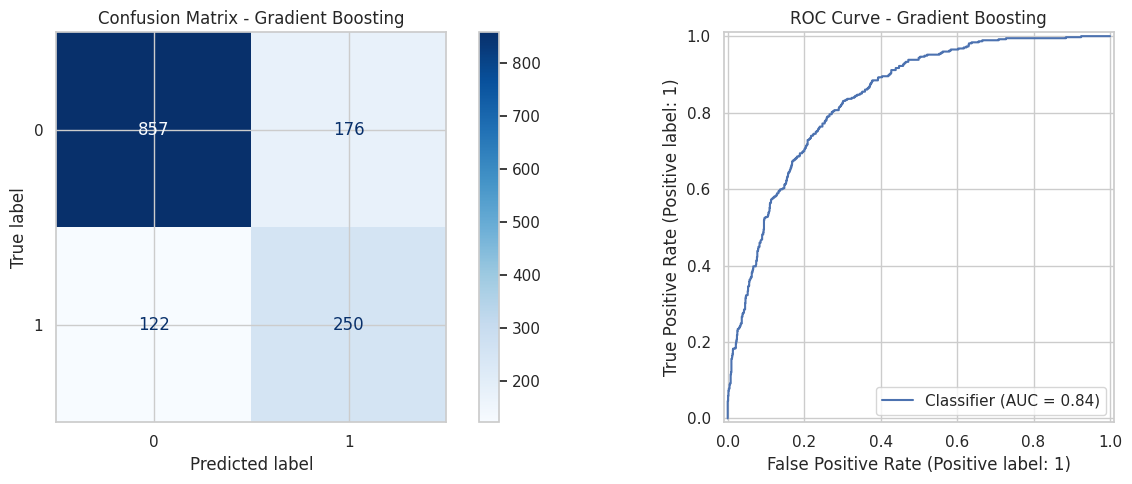

In [8]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print("Best baseline model:", best_model_name)
print(classification_report(y_test, best_pred))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=ax[0], cmap="Blues")
ax[0].set_title(f"Confusion Matrix - {best_model_name}")
RocCurveDisplay.from_predictions(y_test, best_prob, ax=ax[1])
ax[1].set_title(f"ROC Curve - {best_model_name}")
plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [9]:
rf_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 8, 12, 16, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print(rf_search.best_params_)
print(rf_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'model__n_estimators': 200, 'model__min_samples_split': 20, 'model__min_samples_leaf': 8, 'model__max_features': 'log2', 'model__max_depth': 20}
0.8440383513129603


# Model Comparison

In [10]:
tuned_model = rf_search.best_estimator_
tuned_pred = tuned_model.predict(X_test)
tuned_prob = tuned_model.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame([
    {
        "Version": f"Baseline - {best_model_name}",
        "Accuracy": accuracy_score(y_test, best_pred),
        "Precision": precision_score(y_test, best_pred),
        "Recall": recall_score(y_test, best_pred),
        "F1 Score": f1_score(y_test, best_pred),
        "ROC-AUC": roc_auc_score(y_test, best_prob)
    },
    {
        "Version": "Tuned Random Forest",
        "Accuracy": accuracy_score(y_test, tuned_pred),
        "Precision": precision_score(y_test, tuned_pred),
        "Recall": recall_score(y_test, tuned_pred),
        "F1 Score": f1_score(y_test, tuned_pred),
        "ROC-AUC": roc_auc_score(y_test, tuned_prob)
    }
])
comparison

,Version,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline - Gradient Boosting,0.78790,0.586854,0.672043,0.626566,0.840486
1,Tuned Random Forest,0.78363,0.579070,0.669355,0.620948,0.839388


# Conclusion

The customer churn prediction project was completed using multiple classification models including Logistic Regression, KNN, Decision Tree, Random Forest, SVC, Gradient Boosting, and XGBoost. Data preprocessing included missing-value handling, duplicate removal, outlier treatment, encoding, scaling, and SMOTE for class imbalance. Models were evaluated using Accuracy, Precision, Recall, F1 Score, ROC-AUC, confusion matrix, and cross-validation. The best-performing model was selected and tuned for better churn prediction performance.